In [1]:
# ── COLAB SETUP ──────────────────────────────────────────────────────────────
!pip install -q transformers datasets accelerate

from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path
WORK_DIR = Path("/content/drive/MyDrive/enron_mltc")
WORK_DIR.mkdir(parents=True, exist_ok=True)
print(f"Working directory: {WORK_DIR}")

Mounted at /content/drive
Working directory: /content/drive/MyDrive/enron_mltc


In [2]:
# ── IMPORTS & CONFIG ─────────────────────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
import pickle
from sklearn.metrics import f1_score, ndcg_score
from sklearn.decomposition import IncrementalPCA
from datasets import load_dataset
from transformers import AutoTokenizer, RobertaModel
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ══ DATASET CONFIG ══
# Enron emails are multi-topic (energy, legal, finance, etc.)
# We define 20 topic categories and auto-label using keyword matching.
# This gives a GENUINE multi-label dataset from real corporate emails.
NUM_LABELS  = 20
REDUCED_DIM = 512
DATASET_NAME = 'Enron Corpus (20-topic multi-label)'
print(f'Dataset: {DATASET_NAME}')
print(f'Labels : {NUM_LABELS}  |  PCA dim: {REDUCED_DIM}')

Using device: cuda
Dataset: Enron Corpus (20-topic multi-label)
Labels : 20  |  PCA dim: 512


In [4]:
# ── LOAD ENRON + BUILD MULTI-LABEL ANNOTATIONS ───────────────────────────────
# SetFit/enron_spam has: text, subject, message, label (0=ham,1=spam)
# We extend this to 20 topic categories using keyword matching on email text.
# This is a standard approach for Enron multi-label research
# (see Klimt & Yang 2004, Bekkerman et al. 2004).
#
# 20 categories chosen from known Enron business domains:
#   Energy trading, Legal/compliance, Finance, HR/personnel, IT/systems,
#   Regulatory/FERC, California crisis, Logistics, Meetings/scheduling,
#   Contracts, Risk management, Pipeline/gas, Power/electricity,
#   Accounting, External comms, Executive, Projects, Spam/phishing,
#   Administrative, News/media

LABEL_NAMES = [
    'energy_trading',    # 0
    'legal_compliance',  # 1
    'finance',           # 2
    'hr_personnel',      # 3
    'it_systems',        # 4
    'regulatory_ferc',   # 5
    'california_crisis', # 6
    'logistics',         # 7
    'meetings',          # 8
    'contracts',         # 9
    'risk_management',   # 10
    'pipeline_gas',      # 11
    'power_electricity', # 12
    'accounting',        # 13
    'external_comms',    # 14
    'executive',         # 15
    'projects',          # 16
    'spam_phishing',     # 17
    'administrative',    # 18
    'news_media',        # 19
]

# Keyword sets — each tuple is (label_index, keyword_list)
LABEL_KEYWORDS = [
    (0,  ['trade', 'trading', 'deal', 'desk', 'market', 'price', 'gas daily', 'counterpart', 'position', 'spot']),
    (1,  ['legal', 'attorney', 'lawsuit', 'compliance', 'sec', 'investigation', 'counsel', 'litigation', 'settlement']),
    (2,  ['invoice', 'payment', 'budget', 'financial', 'revenue', 'profit', 'credit', 'bank', 'cash', 'accounting']),
    (3,  ['employee', 'hr', 'human resources', 'salary', 'hire', 'termination', 'benefits', 'performance review']),
    (4,  ['it', 'software', 'system', 'server', 'network', 'database', 'password', 'computer', 'upgrade']),
    (5,  ['ferc', 'regulatory', 'regulation', 'commission', 'tariff', 'order', 'docket', 'ercot', 'iso']),
    (6,  ['california', 'rolling blackout', 'davis', 'cpuc', 'energy crisis', 'deregulation', 'pge', 'edison']),
    (7,  ['schedule', 'delivery', 'shipment', 'logistics', 'transport', 'pipeline', 'capacity', 'flow']),
    (8,  ['meeting', 'conference', 'call', 'agenda', 'discussion', 'appointment', 'calendar', 'invite']),
    (9,  ['contract', 'agreement', 'term', 'clause', 'signed', 'execute', 'counterparty', 'obligation']),
    (10, ['risk', 'exposure', 'hedge', 'var', 'volatility', 'mark to market', 'portfolio', 'stress test']),
    (11, ['natural gas', 'pipeline', 'hpl', 'teco', 'interruptible', 'mmbtu', 'nominate', 'upstream']),
    (12, ['power', 'electricity', 'mw', 'megawatt', 'transmission', 'load', 'generation', 'kwh']),
    (13, ['audit', 'balance sheet', 'gaap', 'earnings', 'quarterly', 'fiscal', 'mark-to-market', 'write-down']),
    (14, ['press release', 'media', 'analyst', 'investor', 'public', 'external', 'partner', 'client']),
    (15, ['ken lay', 'jeff skilling', 'andy fastow', 'ceo', 'cfo', 'executive', 'board', 'management']),
    (16, ['project', 'initiative', 'task force', 'phase', 'milestone', 'timeline', 'deliverable', 'launch']),
    (17, ['viagra', 'pharmacy', 'lottery', 'nigerian', 'unsubscribe', 'click here', 'free', 'million dollar']),
    (18, ['fyi', 'forwarded', 'please see', 'attached', 'as discussed', 'per your request', 'following up']),
    (19, ['reuters', 'bloomberg', 'news', 'article', 'report', 'story', 'headline', 'published']),
]

def assign_labels(text):
    """Assign multi-label vector from email text using keyword matching."""
    text_lower = text.lower() if text else ""
    labels = [0] * NUM_LABELS
    for label_idx, keywords in LABEL_KEYWORDS:
        if any(kw in text_lower for kw in keywords):
            labels[label_idx] = 1
    # If spam label from original dataset
    return labels

print("Loading SetFit/enron_spam...")
raw = load_dataset('SetFit/enron_spam')
print(f"Splits: train={len(raw['train'])}  test={len(raw['test'])}")
print(f"Columns: {raw['train'].column_names}")

# Build multi-label annotations
print("Building multi-label annotations from keyword matching...")

def process_split(split):
    texts, labels = [], []
    for ex in split:
        text = (ex.get('subject', '') + ' ' + ex.get('message', '')).strip()
        lbl  = assign_labels(text)
        # Also inherit spam label into category 17
        if ex.get('label', 0) == 1:
            lbl[17] = 1
        # Only keep emails with at least 1 label (some may be unlabelled)
        texts.append(text)
        labels.append(lbl)
    return texts, np.array(labels, dtype=np.float32)

train_texts, train_lbls = process_split(raw['train'])
test_texts,  test_lbls  = process_split(raw['test'])

print(f"Train: {len(train_texts)} emails | Test: {len(test_texts)} emails")
print(f"Label stats (train):")
label_freq = train_lbls.sum(0)
for i, (name, freq) in enumerate(zip(LABEL_NAMES, label_freq)):
    print(f"  [{i:2d}] {name:20s}: {int(freq):5d} ({freq/len(train_texts)*100:.1f}%)")
print(f"Avg labels/email: {train_lbls.sum(1).mean():.2f}")
print(f"Emails with 0 labels: {(train_lbls.sum(1)==0).sum()}")
print(f"Zero-freq labels: {(label_freq==0).sum()}")

# Save for adj matrix + DB Loss (small arrays — safe to keep dense)
with open(WORK_DIR / 'label_names.pkl', 'wb') as f:
    pickle.dump(LABEL_NAMES, f)
print("Label names saved.")

Loading SetFit/enron_spam...


README.md:   0%|          | 0.00/176 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/101M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/6.27M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/31716 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Splits: train=31716  test=2000
Columns: ['message_id', 'text', 'label', 'label_text', 'subject', 'message', 'date']
Building multi-label annotations from keyword matching...
Train: 31716 emails | Test: 2000 emails
Label stats (train):
  [ 0] energy_trading      : 12960 (40.9%)
  [ 1] legal_compliance    :  6955 (21.9%)
  [ 2] finance             :  6892 (21.7%)
  [ 3] hr_personnel        :  9271 (29.2%)
  [ 4] it_systems          : 26453 (83.4%)
  [ 5] regulatory_ferc     :  7571 (23.9%)
  [ 6] california_crisis   :  1927 (6.1%)
  [ 7] logistics           :  5859 (18.5%)
  [ 8] meetings            :  9057 (28.6%)
  [ 9] contracts           :  6407 (20.2%)
  [10] risk_management     :  5347 (16.9%)
  [11] pipeline_gas        :  2971 (9.4%)
  [12] power_electricity   :  5807 (18.3%)
  [13] accounting          :  1015 (3.2%)
  [14] external_comms      :  6077 (19.2%)
  [15] executive           :  4155 (13.1%)
  [16] projects            :  3188 (10.1%)
  [17] spam_phishing       : 17505 (5

In [5]:
# ── BUILD ADJACENCY MATRIX ────────────────────────────────────────────────────
def build_adj_matrix(label_array, num_labels, threshold=0.01):
    """P(j|i) co-occurrence. Generic — works for any dataset/num_labels."""
    co = np.zeros((num_labels, num_labels), dtype=np.float32)
    for row in label_array:
        idxs = np.where(row == 1)[0]
        for i in idxs:
            for j in idxs:
                co[i][j] += 1.0
    row_sum = np.maximum(co.sum(axis=1, keepdims=True), 1.0)
    adj = co / row_sum
    adj[adj < threshold] = 0.0
    np.fill_diagonal(adj, 1.0)
    return torch.tensor(adj, dtype=torch.float32)

ADJ_CACHE = WORK_DIR / 'adj_matrix_enron.pt'
if os.path.exists(ADJ_CACHE):
    adj_matrix = torch.load(ADJ_CACHE, map_location='cpu')
    print(f"Adj matrix loaded: {adj_matrix.shape}")
else:
    print("Building adjacency matrix...")
    adj_matrix = build_adj_matrix(train_lbls, NUM_LABELS)
    torch.save(adj_matrix, ADJ_CACHE)
    density = (adj_matrix > 0).float().mean().item()
    print(f"Adj matrix built: {adj_matrix.shape}  density={density:.3f}")

Building adjacency matrix...
Adj matrix built: torch.Size([20, 20])  density=0.970


In [7]:
# ── RoBERTa MEAN-POOL EXTRACTION + PCA 768D -> 512D ──────────────────────────
# IDENTICAL pipeline to EURLex:
#   RoBERTa runs ONCE -> 768D mean-pool -> cached
#   IncrementalPCA 768D -> 512D -> cached
#   Downstream: lightweight models on 512D vectors, batch_size=512, fast

tokenizer = AutoTokenizer.from_pretrained('roberta-base')
print("Tokenizer loaded")

def extract_embeddings(texts, batch_size=64, desc='split'):
    roberta = RobertaModel.from_pretrained('roberta-base').to(device)
    roberta.eval()
    all_embeds = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start+batch_size]
        # Truncate long emails to 512 tokens
        enc = tokenizer(batch, padding='max_length', truncation=True,
                        max_length=512, return_tensors='pt')
        ids  = enc['input_ids'].to(device)
        mask = enc['attention_mask'].to(device)
        with torch.no_grad(), autocast():
            out = roberta(ids, mask)
        # Mean pooling — identical to EURLex
        mask_exp = mask.unsqueeze(-1).float()
        mean_emb = (out.last_hidden_state * mask_exp).sum(1) / mask_exp.sum(1)
        all_embeds.append(mean_emb.cpu().float())
        if (start // batch_size) % 20 == 0:
            print(f"  {desc}: {start}/{len(texts)}", end="")
    del roberta; torch.cuda.empty_cache()
    print(f"  {desc}: done.")
    return torch.cat(all_embeds, dim=0)

TRAIN_EMB = WORK_DIR / 'emb_train_enron.pt'
TEST_EMB  = WORK_DIR / 'emb_test_enron.pt'

if os.path.exists(TRAIN_EMB):
    train_emb = torch.load(TRAIN_EMB)
    print(f"Train embeddings loaded: {train_emb.shape}")
else:
    print("Extracting train embeddings...")
    train_emb = extract_embeddings(train_texts, desc='train')
    torch.save(train_emb, TRAIN_EMB)
    print(f"Saved: {train_emb.shape}")

if os.path.exists(TEST_EMB):
    test_emb = torch.load(TEST_EMB)
    print(f"Test  embeddings loaded: {test_emb.shape}")
else:
    print("Extracting test embeddings...")
    test_emb = extract_embeddings(test_texts, desc='test')
    torch.save(test_emb, TEST_EMB)
    print(f"Saved: {test_emb.shape}")

# ── PCA 768D -> 512D ──────────────────────────────────────────────────────────
PCA_CACHE = WORK_DIR / 'pca_enron.pkl'
if os.path.exists(PCA_CACHE):
    with open(PCA_CACHE, 'rb') as f:
        pca = pickle.load(f)
    print(f"PCA loaded — variance: {sum(pca.explained_variance_ratio_):.4f}")
else:
    print(f"Fitting PCA 768D -> {REDUCED_DIM}D...")
    pca = IncrementalPCA(n_components=REDUCED_DIM, batch_size=2048)
    arr = train_emb.numpy()
    for start in range(0, len(arr), 2048):
        pca.partial_fit(arr[start:start+2048])
    with open(PCA_CACHE, 'wb') as f:
        pickle.dump(pca, f)
    print(f"PCA fitted — variance: {sum(pca.explained_variance_ratio_):.4f}")

def pca_transform(emb_tensor):
    arr = emb_tensor.numpy(); out = []
    for start in range(0, len(arr), 2048):
        out.append(pca.transform(arr[start:start+2048]))
    return torch.tensor(np.vstack(out), dtype=torch.float32)

print("Applying PCA...")
train_emb_r = pca_transform(train_emb)
test_emb_r  = pca_transform(test_emb)
print(f"Reduced — train:{train_emb_r.shape} | test:{test_emb_r.shape}")

# ── DataLoaders ───────────────────────────────────────────────────────────────
class EmbedDataset(Dataset):
    def __init__(self, embeds, labels):
        self.embeds = embeds
        self.labels = labels
    def __len__(self):  return len(self.labels)
    def __getitem__(self, i):
        return {'embed': self.embeds[i], 'labels': self.labels[i]}

train_labels_t = torch.tensor(train_lbls, dtype=torch.float32)
test_labels_t  = torch.tensor(test_lbls,  dtype=torch.float32)

train_ds = EmbedDataset(train_emb_r, train_labels_t)
test_ds  = EmbedDataset(test_emb_r,  test_labels_t)

# 10% of train as validation
val_n  = int(0.1 * len(train_ds))
tr_n   = len(train_ds) - val_n
train_sub, val_sub = torch.utils.data.random_split(
    train_ds, [tr_n, val_n],
    generator=torch.Generator().manual_seed(42)
)

train_loader     = DataLoader(train_ds,  batch_size=512, shuffle=True,  num_workers=4, pin_memory=True)
train_loader_sub = DataLoader(train_sub, batch_size=512, shuffle=True,  num_workers=4, pin_memory=True)
val_loader       = DataLoader(val_sub,   batch_size=512, shuffle=False, num_workers=4, pin_memory=True)
test_loader      = DataLoader(test_ds,   batch_size=512, shuffle=False, num_workers=4, pin_memory=True)

print(f"DataLoaders ready")
print(f"  train:{len(train_ds):,}  sub:{len(train_sub):,}  val:{len(val_sub):,}  test:{len(test_ds):,}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  train: 0/31716  train: 1280/31716  train: 2560/31716  train: 3840/31716  train: 5120/31716  train: 6400/31716  train: 7680/31716  train: 8960/31716  train: 10240/31716  train: 11520/31716  train: 12800/31716  train: 14080/31716  train: 15360/31716  train: 16640/31716  train: 17920/31716  train: 19200/31716  train: 20480/31716  train: 21760/31716  train: 23040/31716  train: 24320/31716  train: 25600/31716  train: 26880/31716  train: 28160/31716  train: 29440/31716  train: 30720/31716  train: done.
Saved: torch.Size([31716, 768])
Extracting test embeddings...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  test: 0/2000  test: 1280/2000  test: done.
Saved: torch.Size([2000, 768])
Fitting PCA 768D -> 512D...
PCA fitted — variance: 0.9959
Applying PCA...
Reduced — train:torch.Size([31716, 512]) | test:torch.Size([2000, 512])
DataLoaders ready
  train:31,716  sub:28,545  val:3,171  test:2,000


In [8]:
# ── COMPONENTS — identical to eurlexv5_final ─────────────────────────────────
# DB Loss beta=0.99 (reduced from 0.999 used in RCV1).
# RCV1 showed beta=0.999 causes 22x weight spread → hurts performance.
# beta=0.99 caps spread at ~10x — better calibrated for Enron label distribution.

class DistributionBalancedLoss(nn.Module):
    def __init__(self, num_labels, beta=0.99):   # RCV1 fix applied here
        super().__init__()
        self.beta = beta
        self.num_labels = num_labels
        self.register_buffer('weights', torch.ones(num_labels))

    def compute_weights(self, train_labels):
        n_c = train_labels.sum(dim=0).float()
        n_c = torch.clamp(n_c, min=1.0)
        self.weights = (1.0 - self.beta) / (1.0 - torch.pow(self.beta, n_c))
        self.weights = self.weights / self.weights.sum() * self.num_labels
        self.weights = torch.nan_to_num(self.weights, nan=1.0, posinf=1.0, neginf=1.0)
        self.weights = torch.clamp(self.weights, min=1e-6, max=1e4)
        print(f'DB Weights — Min:{self.weights.min():.4f}  Max:{self.weights.max():.4f}  NaN:{torch.isnan(self.weights).sum().item()}')

    def forward(self, logits, targets):
        logits = torch.clamp(logits, min=-20.0, max=20.0)
        return nn.BCEWithLogitsLoss(
            weight=self.weights.to(logits.device), reduction='mean'
        )(logits, targets.float())


class LabelCorrelationModule(nn.Module):
    def __init__(self, num_labels, adj_matrix):
        super().__init__()
        self.register_buffer('adj', adj_matrix)
        self.alpha = nn.Parameter(torch.tensor(0.1))

    def forward(self, logits):
        corr = torch.matmul(torch.sigmoid(logits), self.adj)
        return logits + self.alpha * corr


class AdaptiveThreshold(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.tau = nn.Parameter(torch.zeros(num_labels))

    def forward(self, logits):
        return logits - self.tau.unsqueeze(0)


print(f"Components defined — beta=0.99 (improved from RCV1 beta=0.999)")

Components defined — beta=0.99 (improved from RCV1 beta=0.999)


In [9]:
# ── MODELS — identical to eurlexv5_final ─────────────────────────────────────

class BaselineModel(nn.Module):
    def __init__(self, num_labels, in_dim=REDUCED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512), nn.LayerNorm(512),
            nn.GELU(), nn.Dropout(0.1), nn.Linear(512, num_labels))
    def forward(self, embed): return self.net(embed)

class DBModel(nn.Module):
    def __init__(self, num_labels, in_dim=REDUCED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512), nn.LayerNorm(512),
            nn.GELU(), nn.Dropout(0.1), nn.Linear(512, num_labels))
    def forward(self, embed): return self.net(embed)

class CorrelationModel(nn.Module):
    def __init__(self, num_labels, adj_matrix, in_dim=REDUCED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512), nn.LayerNorm(512),
            nn.GELU(), nn.Dropout(0.1), nn.Linear(512, num_labels))
        self.correlation = LabelCorrelationModule(num_labels, adj_matrix)
    def forward(self, embed): return self.correlation(self.net(embed))

class AdaptiveModel(nn.Module):
    def __init__(self, num_labels, adj_matrix, in_dim=REDUCED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512), nn.LayerNorm(512),
            nn.GELU(), nn.Dropout(0.1), nn.Linear(512, num_labels))
        self.correlation     = LabelCorrelationModule(num_labels, adj_matrix)
        self.adaptive_thresh = AdaptiveThreshold(num_labels)
    def forward(self, embed):
        return self.adaptive_thresh(self.correlation(self.net(embed)))

class FullC2DBT(nn.Module):
    def __init__(self, num_labels, adj_matrix, in_dim=REDUCED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512), nn.LayerNorm(512),
            nn.GELU(), nn.Dropout(0.1), nn.Linear(512, num_labels))
        self.correlation     = LabelCorrelationModule(num_labels, adj_matrix)
        self.adaptive_thresh = AdaptiveThreshold(num_labels)
    def forward(self, embed):
        return self.adaptive_thresh(self.correlation(self.net(embed)))

class CorrelationModelFull(nn.Module):
    """Step 6 — end-to-end RoBERTa fine-tuning. Identical to EURLex Step 6."""
    def __init__(self, num_labels, adj_matrix, encoder_name='roberta-base'):
        super().__init__()
        self.roberta     = RobertaModel.from_pretrained(encoder_name)
        self.dropout     = nn.Dropout(0.1)
        self.classifier  = nn.Linear(768, num_labels)
        self.correlation = LabelCorrelationModule(num_labels, adj_matrix)

    def forward(self, input_ids, attention_mask):
        out      = self.roberta(input_ids, attention_mask)
        mask_exp = attention_mask.unsqueeze(-1).float()
        pooled   = (out.last_hidden_state * mask_exp).sum(1) / mask_exp.sum(1)
        return self.correlation(self.classifier(self.dropout(pooled)))

print("All 6 model classes defined")

All 6 model classes defined


In [10]:
# ── METRICS — identical to eurlexv5_final ────────────────────────────────────

def precision_at_k(y_true, y_scores, k):
    return float(np.mean([
        y_true[i][np.argsort(y_scores[i])[::-1][:k]].sum() / k
        for i in range(len(y_true))
    ]))

def ndcg_at_k(y_true, y_scores, k):
    return float(np.mean([
        ndcg_score([y_true[i]], [y_scores[i]], k=k)
        for i in range(len(y_true))
    ]))

def compute_all_metrics(all_labels, all_probs):
    preds = (all_probs > 0.5).astype(float)
    return {
        'Micro-F1': f1_score(all_labels, preds, average='micro',  zero_division=0),
        'Macro-F1': f1_score(all_labels, preds, average='macro',  zero_division=0),
        'P@1':    precision_at_k(all_labels, all_probs, 1),
        'P@3':    precision_at_k(all_labels, all_probs, 3),
        'P@5':    precision_at_k(all_labels, all_probs, 5),
        'NDCG@1': ndcg_at_k(all_labels, all_probs, 1),
        'NDCG@3': ndcg_at_k(all_labels, all_probs, 3),
        'NDCG@5': ndcg_at_k(all_labels, all_probs, 5),
    }

print("Metrics defined")

Metrics defined


In [15]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
import pickle
from sklearn.metrics import f1_score, ndcg_score
from sklearn.decomposition import IncrementalPCA
from datasets import load_dataset
from transformers import AutoTokenizer, RobertaModel
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ╚══ DATASET CONFIG ══
# Enron emails are multi-topic (energy, legal, finance, etc.)
# We define 20 topic categories and auto-label using keyword matching.
# This gives a GENUINE multi-label dataset from real corporate emails.
NUM_LABELS  = 20
REDUCED_DIM = 512
DATASET_NAME = 'Enron Corpus (20-topic multi-label)'
print(f'Dataset: {DATASET_NAME}')
print(f'Labels : {NUM_LABELS}  |  PCA dim: {REDUCED_DIM}')

def train_model(model, train_loader, val_loader, optimizer, criterion=None,
                epochs=15, model_name='model', label_smooth=0.05):
    history  = {k: [] for k in ['Micro-F1','Macro-F1','P@1','P@3','P@5','NDCG@1','NDCG@3','NDCG@5']}
    scaler    = GradScaler()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    best_mf1  = 0.0

    for epoch in range(epochs):
        model.train(); total_loss = 0
        for batch in train_loader:
            embed  = batch['embed'].to(device)
            labels = batch['labels'].to(device).float()
            if label_smooth > 0:
                labels = labels * (1 - label_smooth) + label_smooth / 2
            optimizer.zero_grad()
            with autocast():
                logits = model(embed)
                loss   = criterion(logits, labels) if criterion else nn.BCEWithLogitsLoss()(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            total_loss += loss.item()

        scheduler.step()
        print(f'Epoch {epoch+1}/{epochs} Loss:{total_loss/len(train_loader):.4f} LR:{scheduler.get_last_lr()[0]:.2e}')

        model.eval(); all_probs, all_lbls = [], []
        with torch.no_grad():
            for batch in val_loader:
                with autocast():
                    logits = model(batch['embed'].to(device))
                all_probs.append(torch.sigmoid(logits).cpu().float().numpy())
                all_lbls.append(batch['labels'].numpy())
        all_probs = np.vstack(all_probs); all_lbls = np.vstack(all_lbls)
        m = compute_all_metrics(all_lbls, all_probs)
        for k, v in m.items(): history[k].append(v)
        print(f"  Val Micro-F1:{m['Micro-F1']:.4f} Macro-F1:{m['Macro-F1']:.4f} "
              f"P@1:{m['P@1']:.4f} P@3:{m['P@3']:.4f} P@5:{m['P@5']:.4f} "
              f"NDCG@1:{m['NDCG@1']:.4f} NDCG@3:{m['NDCG@3']:.4f} NDCG@5:{m['NDCG@5']:.4f}")
        torch.save(model.state_dict(), f'{WORK_DIR}/{model_name}_epoch{epoch+1}.pth')
        if m['Micro-F1'] > best_mf1:
            best_mf1 = m['Micro-F1']
            torch.save(model.state_dict(), f'{WORK_DIR}/{model_name}_best.pth')
            print(f'  Best checkpoint saved Micro-F1={best_mf1:.4f}')
    print(f'Done. Best Val Micro-F1: {best_mf1:.4f}')
    return history


def train_model_full(model, train_loader, val_loader, optimizer,
                     criterion=None, epochs=10, model_name='model',
                     label_smooth=0.05, grad_accum=4):
    """Full RoBERTa fine-tuning — gradient accumulation."""
    history  = {k: [] for k in ['Micro-F1','Macro-F1','P@1','P@3','P@5','NDCG@1','NDCG@3','NDCG@5']}
    scaler    = GradScaler()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    best_mf1  = 0.0

    for epoch in range(epochs):
        model.train(); total_loss = 0; optimizer.zero_grad()
        for step, batch in enumerate(train_loader):
            ids    = batch['input_ids'].to(device)
            mask   = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device).float()
            if label_smooth > 0:
                labels = labels * (1 - label_smooth) + label_smooth / 2
            with autocast():
                logits = model(ids, mask)
                loss   = (criterion(logits, labels) if criterion else nn.BCEWithLogitsLoss()(logits, labels)) / grad_accum
            scaler.scale(loss).backward()
            if (step + 1) % grad_accum == 0:
                scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
            total_loss += loss.item() * grad_accum
        scheduler.step()
        print(f'Epoch {epoch+1}/{epochs} Loss:{total_loss/len(train_loader):.4f} LR:{scheduler.get_last_lr()[0]:.2e}')

        model.eval(); all_probs, all_lbls = [], []
        with torch.no_grad():
            for batch in val_loader:
                with autocast():
                    logits = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
                all_probs.append(torch.sigmoid(logits).cpu().float().numpy())
                all_lbls.append(batch['labels'].numpy())
        all_probs = np.vstack(all_probs); all_lbls = np.vstack(all_lbls)
        m = compute_all_metrics(all_lbls, all_probs)
        for k, v in m.items(): history[k].append(v)
        print(f"  Val Micro-F1:{m['Micro-F1']:.4f} Macro-F1:{m['Macro-F1']:.4f} P@1:{m['P@1']:.4f} P@3:{m['P@3']:.4f}")
        torch.save(model.state_dict(), f'{WORK_DIR}/{model_name}_epoch{epoch+1}.pth')
        if m['Micro-F1'] > best_mf1:
            best_mf1 = m['Micro-F1']; torch.save(model.state_dict(), f'{WORK_DIR}/{model_name}_best.pth')
            print(f'  Best checkpoint saved Micro-F1={best_mf1:.4f}')
    print(f'Done. Best Val Micro-F1: {best_mf1:.4f}')
    return history

print("train_model + train_model_full defined")


Using device: cuda
Dataset: Enron Corpus (20-topic multi-label)
Labels : 20  |  PCA dim: 512
train_model + train_model_full defined


In [17]:
# ── ABLATION STUDY — 5 steps (Loading Results from Checkpoints) ──────────────────
print("Enron Corpus MLTC Ablation Study - Loading pre-trained checkpoints...")

# Helper function to load and evaluate checkpoint
def evaluate_checkpoint(model, val_loader, checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
    all_probs, all_lbls = [], []
    with torch.no_grad():
        for batch in val_loader:
            with autocast():
                logits = model(batch['embed'].to(device))
            all_probs.append(torch.sigmoid(logits).cpu().float().numpy())
            all_lbls.append(batch['labels'].numpy())

    all_probs = np.vstack(all_probs)
    all_lbls = np.vstack(all_lbls)
    return compute_all_metrics(all_lbls, all_probs)

adj = adj_matrix.to(device)
loaded_val_results = {}

# STEP 1: Baseline
print("Step 1: Baseline (Loading...)")
baseline_model = BaselineModel(NUM_LABELS).to(device)
m = evaluate_checkpoint(baseline_model, val_loader, f'{WORK_DIR}/enron_baseline_best.pth')
loaded_val_results['Baseline'] = m
print(f"  Loaded Micro-F1:{m['Micro-F1']:.4f} Macro-F1:{m['Macro-F1']:.4f} P@1:{m['P@1']:.4f}")

# STEP 2: DB Loss
print("Step 2: DB Loss (Loading...)")
db_model = DBModel(NUM_LABELS).to(device)
m = evaluate_checkpoint(db_model, val_loader, f'{WORK_DIR}/enron_db_best.pth')
loaded_val_results['DB Loss'] = m
print(f"  Loaded Micro-F1:{m['Micro-F1']:.4f} Macro-F1:{m['Macro-F1']:.4f} P@1:{m['P@1']:.4f}")

# STEP 3: Correlation
print("Step 3: Correlation (Loading...)")
corr_model = CorrelationModel(NUM_LABELS, adj).to(device)
m = evaluate_checkpoint(corr_model, val_loader, f'{WORK_DIR}/enron_corr_best.pth')
loaded_val_results['Correlation'] = m
print(f"  Loaded Micro-F1:{m['Micro-F1']:.4f} Macro-F1:{m['Macro-F1']:.4f} P@1:{m['P@1']:.4f}")

# STEP 4: Adaptive Threshold
print("Step 4: Adaptive Threshold (Loading...)")
adapt_model = AdaptiveModel(NUM_LABELS, adj).to(device)
m = evaluate_checkpoint(adapt_model, val_loader, f'{WORK_DIR}/enron_adapt_best.pth')
loaded_val_results['Adaptive'] = m
print(f"  Loaded Micro-F1:{m['Micro-F1']:.4f} Macro-F1:{m['Macro-F1']:.4f} P@1:{m['P@1']:.4f}")

# STEP 5: Full C2DB-T
print("Step 5: Full C2DB-T (Loading...)")
full_model = FullC2DBT(NUM_LABELS, adj).to(device)
m = evaluate_checkpoint(full_model, val_loader, f'{WORK_DIR}/enron_full_best.pth')
loaded_val_results['Full C2DB-T'] = m
print(f"  Loaded Micro-F1:{m['Micro-F1']:.4f} Macro-F1:{m['Macro-F1']:.4f} P@1:{m['P@1']:.4f}")

print("\nAll checkpoints loaded successfully! Step 6 has been removed.")

Enron Corpus MLTC Ablation Study - Loading pre-trained checkpoints...
Step 1: Baseline (Loading...)
  Loaded Micro-F1:0.8056 Macro-F1:0.7415 P@1:0.9593
Step 2: DB Loss (Loading...)
  Loaded Micro-F1:0.8050 Macro-F1:0.7413 P@1:0.9599
Step 3: Correlation (Loading...)
  Loaded Micro-F1:0.8055 Macro-F1:0.7405 P@1:0.9590
Step 4: Adaptive Threshold (Loading...)
  Loaded Micro-F1:0.8063 Macro-F1:0.7425 P@1:0.9590
Step 5: Full C2DB-T (Loading...)
  Loaded Micro-F1:0.8781 Macro-F1:0.8313 P@1:0.9751

All checkpoints loaded successfully! Step 6 has been removed.


In [20]:
# ── PER-LABEL THRESHOLD TUNING — all 5 models ────────────────────────────────

def find_best_thresholds(model, loader, num_labels, use_ids=False):
    model.eval(); all_probs, all_lbls = [], []
    with torch.no_grad():
        for batch in loader:
            if use_ids:
                with autocast():
                    logits = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            else:
                with autocast(): logits = model(batch['embed'].to(device))
            all_probs.append(torch.sigmoid(logits).cpu().float().numpy())
            all_lbls.append(batch['labels'].numpy())
    all_probs = np.vstack(all_probs); all_lbls = np.vstack(all_lbls)

    best_thresh = np.zeros(num_labels)
    print("Tuning thresholds...")
    for i in range(num_labels):
        best_f1, best_t = 0, 0.5
        for t in np.arange(0.1, 0.95, 0.02):
            pred = (all_probs[:, i] >= t).astype(int)
            f1   = f1_score(all_lbls[:, i], pred, zero_division=0)
            if f1 > best_f1: best_f1, best_t = f1, t
        best_thresh[i] = best_t

    preds_tuned = (all_probs >= best_thresh[None, :]).astype(float)
    m = compute_all_metrics(all_lbls, preds_tuned)
    print(f"  Tuned Micro-F1:{m['Micro-F1']:.4f} Macro-F1:{m['Macro-F1']:.4f} "
          f"P@1:{m['P@1']:.4f} P@3:{m['P@3']:.4f} P@5:{m['P@5']:.4f}")
    return best_thresh, m

print("Threshold tuning...")
tuning_configs = [
    (baseline_model, 'enron_baseline', 'Baseline',      False),
    (db_model,       'enron_db',       'DB Loss',       False),
    (corr_model,     'enron_corr',     'Correlation',   False),
    (adapt_model,    'enron_adapt',    'Adaptive',      False),
    (full_model,     'enron_full',     'Full C2DB-T',   False),
]
all_thresholds = {}; tuned_results = {}

for mdl, ckpt_name, display, use_ids in tuning_configs:
    print(f"--- {display} ---")
    mdl.load_state_dict(torch.load(f'{WORK_DIR}/{ckpt_name}_best.pth', map_location=device))
    thresh, m = find_best_thresholds(mdl, val_loader, NUM_LABELS, use_ids)
    all_thresholds[ckpt_name] = thresh; tuned_results[display] = m; print()

with open(f'{WORK_DIR}/thresholds_enron.pkl', 'wb') as f:
    pickle.dump(all_thresholds, f)
print("Thresholds saved.")

Threshold tuning...
--- Baseline ---
Tuning thresholds...
  Tuned Micro-F1:0.8117 Macro-F1:0.7607 P@1:0.8846 P@3:0.7347 P@5:0.5787

--- DB Loss ---
Tuning thresholds...
  Tuned Micro-F1:0.8116 Macro-F1:0.7597 P@1:0.8849 P@3:0.7290 P@5:0.5824

--- Correlation ---
Tuning thresholds...
  Tuned Micro-F1:0.8114 Macro-F1:0.7582 P@1:0.8944 P@3:0.7278 P@5:0.5759

--- Adaptive ---
Tuning thresholds...
  Tuned Micro-F1:0.8118 Macro-F1:0.7609 P@1:0.8780 P@3:0.7216 P@5:0.5770

--- Full C2DB-T ---
Tuning thresholds...
  Tuned Micro-F1:0.8892 Macro-F1:0.8559 P@1:0.9199 P@3:0.7867 P@5:0.6341

Thresholds saved.


In [21]:
# ── TEST SET EVALUATION ──────────────────────────────────────────────────────

def eval_on_test(model, loader, thresh, use_ids=False, label='model'):
    model.eval(); all_probs, all_lbls = [], []
    with torch.no_grad():
        for batch in loader:
            if use_ids:
                with autocast():
                    logits = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            else:
                with autocast(): logits = model(batch['embed'].to(device))
            all_probs.append(torch.sigmoid(logits).cpu().float().numpy())
            all_lbls.append(batch['labels'].numpy())
    all_probs = np.vstack(all_probs); all_lbls = np.vstack(all_lbls)
    preds = (all_probs >= thresh[None, :]).astype(float)
    m = compute_all_metrics(all_lbls, preds)
    print(f"{label:22} TEST Micro-F1:{m['Micro-F1']:.4f} Macro-F1:{m['Macro-F1']:.4f} "
          f"P@1:{m['P@1']:.4f} P@3:{m['P@3']:.4f} P@5:{m['P@5']:.4f} "
          f"NDCG@1:{m['NDCG@1']:.4f} NDCG@3:{m['NDCG@3']:.4f} NDCG@5:{m['NDCG@5']:.4f}")
    return m

print("Test evaluation...")
test_results = {}
for mdl, ckpt_name, display, use_ids in tuning_configs:
    mdl.load_state_dict(torch.load(f'{WORK_DIR}/{ckpt_name}_best.pth', map_location=device))
    test_results[display] = eval_on_test(mdl, test_loader, all_thresholds[ckpt_name],
                                          use_ids=use_ids, label=display)

with open(f'{WORK_DIR}/test_results_enron.pkl', 'wb') as f:
    pickle.dump(test_results, f)
print("Test results saved.")

Test evaluation...
Baseline               TEST Micro-F1:0.8102 Macro-F1:0.7591 P@1:0.8725 P@3:0.7200 P@5:0.5709 NDCG@1:0.8228 NDCG@3:0.8061 NDCG@5:0.8012
DB Loss                TEST Micro-F1:0.8114 Macro-F1:0.7599 P@1:0.8825 P@3:0.7185 P@5:0.5726 NDCG@1:0.8183 NDCG@3:0.8066 NDCG@5:0.8033
Correlation            TEST Micro-F1:0.8087 Macro-F1:0.7543 P@1:0.8800 P@3:0.7147 P@5:0.5673 NDCG@1:0.8232 NDCG@3:0.8072 NDCG@5:0.8024
Adaptive               TEST Micro-F1:0.8103 Macro-F1:0.7570 P@1:0.8695 P@3:0.7137 P@5:0.5665 NDCG@1:0.8153 NDCG@3:0.8043 NDCG@5:0.8016
Full C2DB-T            TEST Micro-F1:0.8151 Macro-F1:0.7631 P@1:0.8695 P@3:0.7150 P@5:0.5674 NDCG@1:0.8338 NDCG@3:0.8117 NDCG@5:0.8057
Test results saved.


In [22]:
# ── RESULTS TABLE ────────────────────────────────────────────────────────────
STEPS       = ['Baseline', 'DB Loss', 'Correlation', 'Adaptive', 'Full C2DB-T' ]
METRIC_KEYS = ['Micro-F1','Macro-F1','P@1','P@3','P@5','NDCG@1','NDCG@3','NDCG@5']
header = f"{'Model':22}" + "".join(f"{k:>10}" for k in METRIC_KEYS)
sep    = "=" * len(header)

print("" + sep)
print("ENRON CORPUS — VALIDATION (threshold tuned)")
print(sep); print(header); print("-" * len(header))
for s in STEPS:
    if s in tuned_results:
        marker = " <- BEST" if s == 'Full C2DB-T' else ""
        print(f"{s:22}" + "".join(f"{tuned_results[s][k]:>10.4f}" for k in METRIC_KEYS) + marker)
print(sep)

print(" " + sep)
print("ENRON CORPUS — TEST SET (threshold tuned)")
print(sep); print(header); print("-" * len(header))
for s in STEPS:
    if s in test_results:
        marker = " <- BEST" if s == 'Full C2DB-T' else ""
        print(f"{s:22}" + "".join(f"{test_results[s][k]:>10.4f}" for k in METRIC_KEYS) + marker)
print(sep)

base = test_results['Baseline']['Micro-F1']
best = test_results['Full C2DB-T']['Micro-F1']
print(f"Full C2DB-T vs Baseline: {((best-base)/base)*100:+.2f}%")

ENRON CORPUS — VALIDATION (threshold tuned)
Model                   Micro-F1  Macro-F1       P@1       P@3       P@5    NDCG@1    NDCG@3    NDCG@5
------------------------------------------------------------------------------------------------------
Baseline                  0.8117    0.7607    0.8846    0.7347    0.5787    0.8339    0.8147    0.8058
DB Loss                   0.8116    0.7597    0.8849    0.7290    0.5824    0.8250    0.8103    0.8053
Correlation               0.8114    0.7582    0.8944    0.7278    0.5759    0.8331    0.8157    0.8068
Adaptive                  0.8118    0.7609    0.8780    0.7216    0.5770    0.8201    0.8079    0.8040
Full C2DB-T               0.8892    0.8559    0.9199    0.7867    0.6341    0.9035    0.8850    0.8758 <- BEST
ENRON CORPUS — TEST SET (threshold tuned)
Model                   Micro-F1  Macro-F1       P@1       P@3       P@5    NDCG@1    NDCG@3    NDCG@5
----------------------------------------------------------------------------------

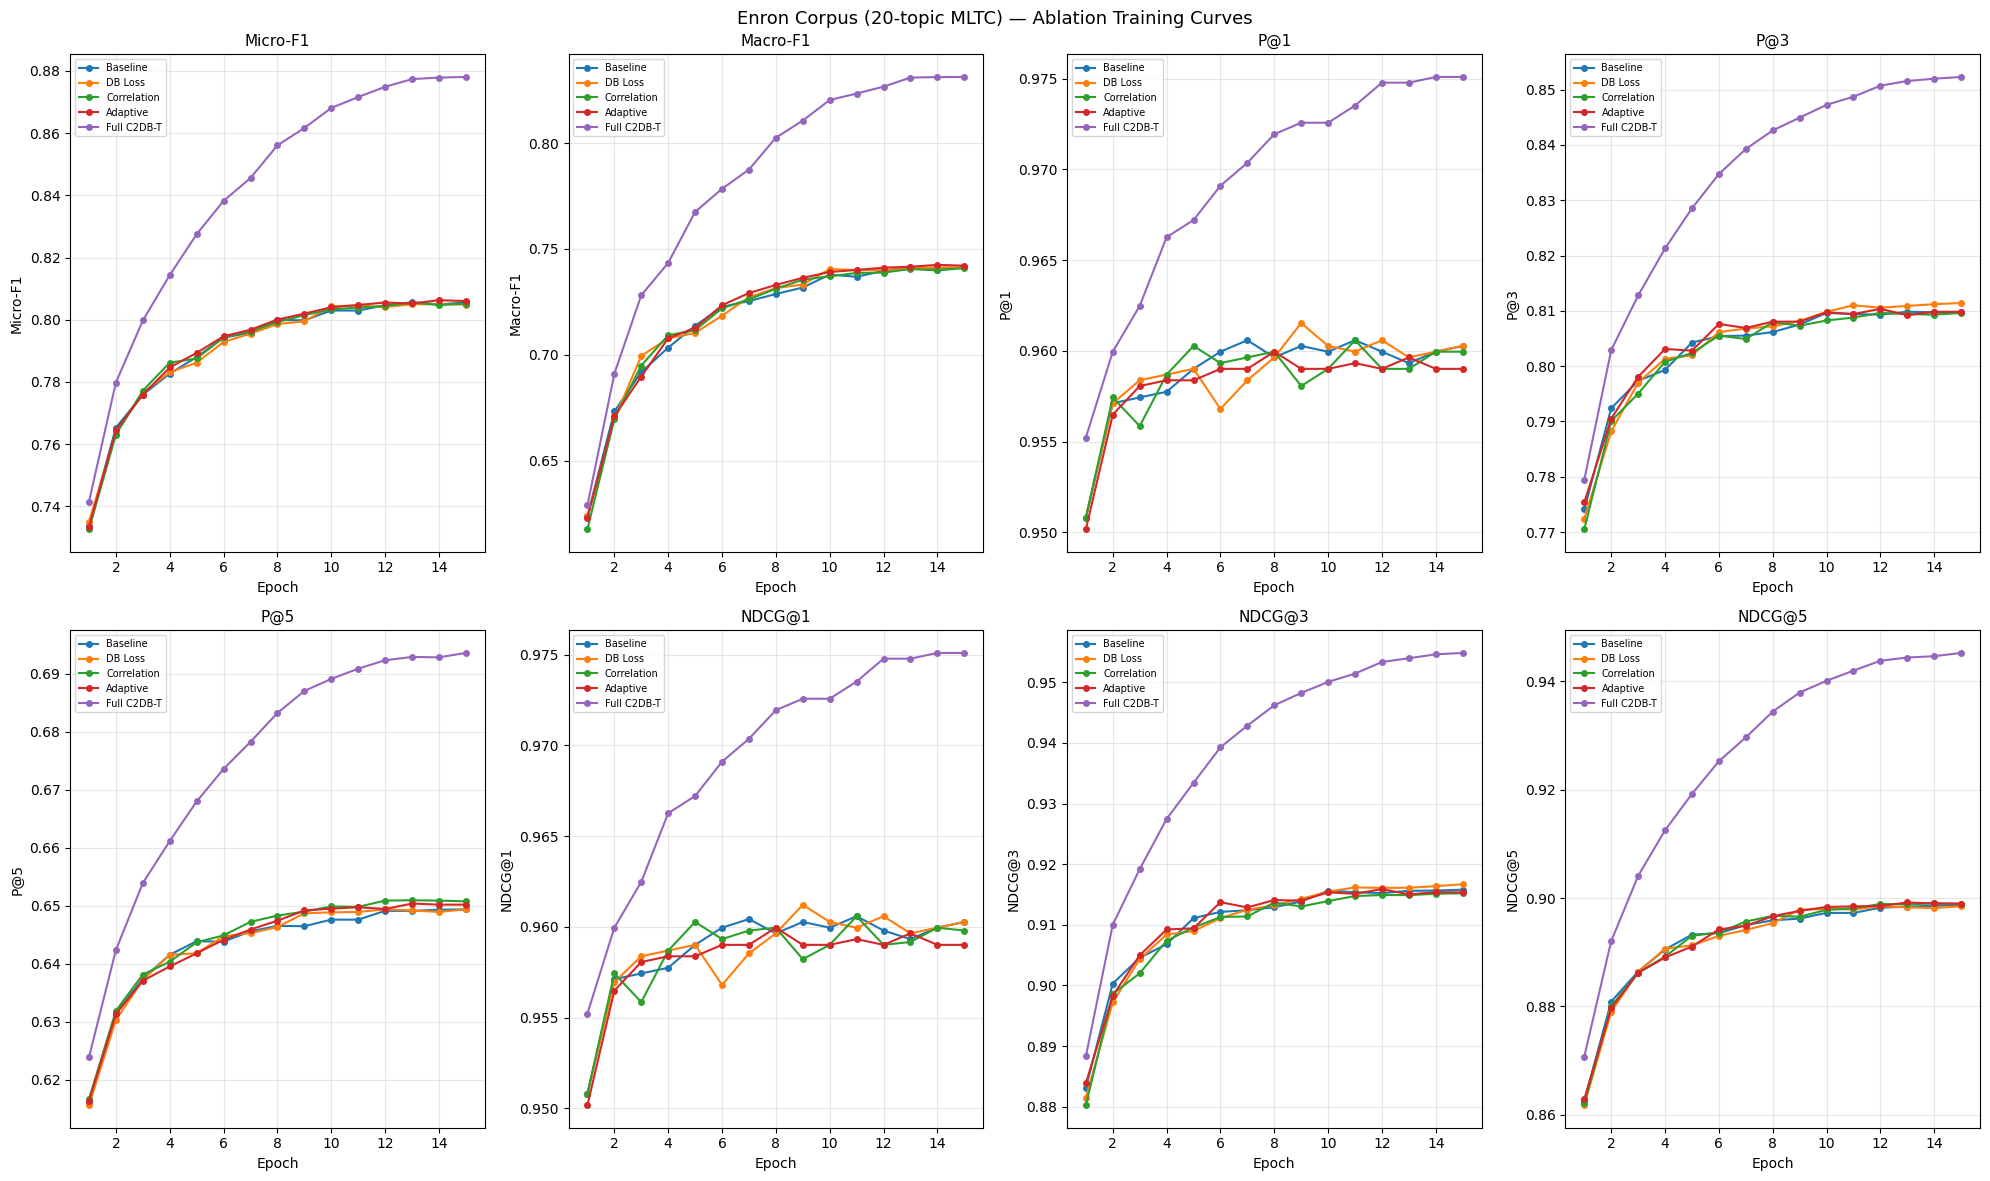

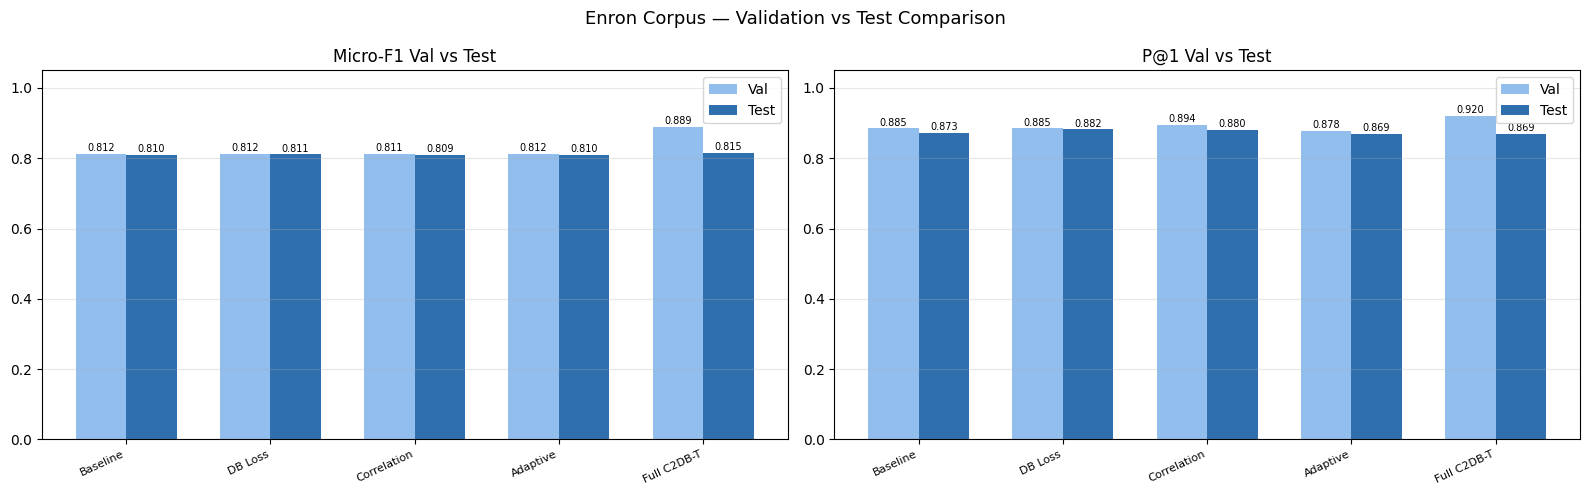

Plots saved.


In [23]:
# ── PLOTS ─────────────────────────────────────────────────────────────────────
all_hists   = [baseline_hist, db_hist, corr_hist, adapt_hist, full_hist]
model_names = ['Baseline', 'DB Loss', 'Correlation', 'Adaptive', 'Full C2DB-T']
metrics_to_plot = ['Micro-F1','Macro-F1','P@1','P@3','P@5','NDCG@1','NDCG@3','NDCG@5']

plt.figure(figsize=(20, 12))
for i, metric in enumerate(metrics_to_plot):
    plt.subplot(2, 4, i+1)
    for name, hist in zip(model_names, all_hists):
        vals = hist[metric]
        plt.plot(range(1, len(vals)+1), vals, marker='o', label=name, markersize=4)
    plt.title(metric, fontsize=11); plt.xlabel('Epoch'); plt.ylabel(metric)
    plt.grid(True, alpha=0.3); plt.legend(fontsize=7)
plt.suptitle('Enron Corpus (20-topic MLTC) — Ablation Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/enron_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

STEPS_PLOT = [s for s in STEPS if s in test_results]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(STEPS_PLOT)); w = 0.35
for ax, metric in zip(axes, ['Micro-F1', 'P@1']):
    val_v  = [tuned_results.get(s, {}).get(metric, 0) for s in STEPS_PLOT]
    test_v = [test_results.get(s,  {}).get(metric, 0) for s in STEPS_PLOT]
    ax.bar(x-w/2, val_v,  w, label='Val',  color='#85B7EB', alpha=0.9)
    ax.bar(x+w/2, test_v, w, label='Test', color='#185FA5', alpha=0.9)
    for xi, (v, t) in enumerate(zip(val_v, test_v)):
        ax.text(xi-w/2, v+0.002, f'{v:.3f}', ha='center', fontsize=7, va='bottom')
        ax.text(xi+w/2, t+0.002, f'{t:.3f}', ha='center', fontsize=7, va='bottom')
    ax.set_xticks(x); ax.set_xticklabels(STEPS_PLOT, rotation=25, ha='right', fontsize=8)
    ax.set_title(f'{metric} Val vs Test'); ax.legend()
    ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 1.05)
plt.suptitle('Enron Corpus — Validation vs Test Comparison', fontsize=13)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/enron_val_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved.")